In [1]:
pip install pandas numpy matplotlib seaborn nltk textblob scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 10.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd

expenses = pd.read_csv("datasets/expenses.csv")

expenses.head()


,Transaction_ID,Transaction_Type,Category,Amount,Date,Season,Weather,Customer_ID,Incident_ID
0,0,Revenue,Ticket Sale,3500,2025-02-25,Winter,Foggy,1415.0,NaN
1,1,Revenue,Ticket Sale,640,2025-02-25,Winter,Windy,5095.0,NaN
2,2,Expense,Ambulance Call,-1490,2025-02-25,Winter,Foggy,NaN,96.0
3,3,Expense,Equipment Maintenance,-730,2025-02-25,Winter,Sunny,NaN,NaN
4,4,Expense,Staff Salary,-4238,2025-02-25,Summer,Sunny,NaN,NaN


In [16]:
category_summary = expenses.groupby('Category')['Amount'].agg(['sum', 'mean']).reset_index()

category_summary.head()



,Category,sum,mean
0,Ambulance Call,-675590,-1723.443878
1,Equipment Maintenance,-240142,-597.368159
2,Rental,50210,122.165450
3,Staff Salary,-2503121,-6484.769430
4,Ticket Sale,594790,1454.254279


   Season      sum         mean
0  Summer -1595223 -1608.087702
1  Winter -1178630 -1169.275794


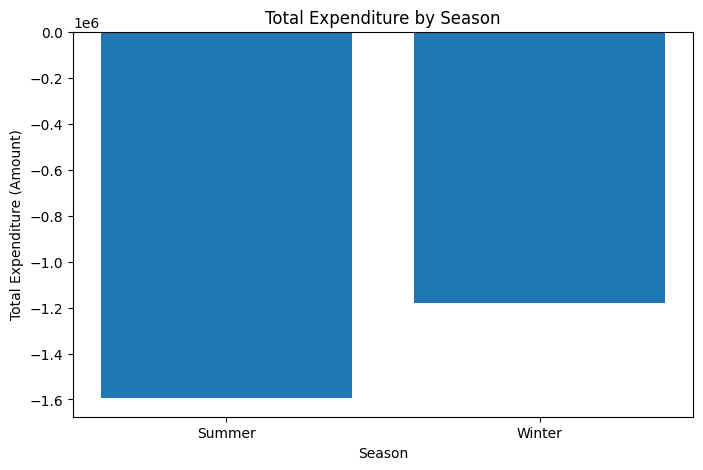

In [17]:
seasonal_summary = expenses.groupby('Season')['Amount'].agg(['sum', 'mean']).reset_index()

print(seasonal_summary)

plt.figure(figsize=(8, 5))
plt.bar(seasonal_summary['Season'], seasonal_summary['sum'])
plt.title('Total Expenditure by Season')
plt.xlabel('Season')
plt.ylabel('Total Expenditure (Amount)')
plt.show()


In [19]:
fixed_cost_categories = ['Salaries', 'Rent', 'Utilities']

expenses['Cost_Type'] = expenses['Category'].apply(lambda x: 'Fixed' if x in fixed_cost_categories else 'Variable')

cost_type_summary = expenses.groupby('Cost_Type')['Amount'].agg(['sum', 'mean']).reset_index()

cost_type_summary



,Cost_Type,sum,mean
0,Variable,-2773853,-1386.9265


In [24]:
transaction_summary = expenses.groupby('Transaction_Type')['Amount'].sum().reset_index()

print(transaction_summary)

total_revenue = transaction_summary.loc[transaction_summary['Transaction_Type'] == 'Revenue', 'Amount'].values[0]
total_expense = transaction_summary.loc[transaction_summary['Transaction_Type'] == 'Expense', 'Amount'].values[0]

profit_margin = ((total_revenue - total_expense) / total_revenue) * 100

print("Overall Profit Margin: {:.2f}%".format(profit_margin))


  Transaction_Type   Amount
0          Expense -3418853
1          Revenue   645000
Overall Profit Margin: 630.05%


In [29]:
seasonal_pivot = expenses.groupby(['Season', 'Transaction_Type'])['Amount'].sum().unstack()

seasonal_pivot['Profit_Margin'] = ((seasonal_pivot['Revenue'] - seasonal_pivot['Expense']) / seasonal_pivot['Revenue']) * 100

print("Seasonal Profitability:")
print(seasonal_pivot)


Seasonal Profitability:
Transaction_Type  Expense  Revenue  Profit_Margin
Season                                           
Summer           -1745053   149830    1264.688647
Winter           -1673800   495170     438.025325


In [30]:
# expenses['Date'] = pd.to_datetime(expenses['Date'])

# expenses.set_index('Date', inplace=True)

# monthly_trends = expenses.resample('M')['Amount'].sum()

# print("Monthly Trends in Expenditure/Revenue:")
# print(monthly_trends.head())

# plt.figure(figsize=(10, 5))
# plt.plot(monthly_trends.index, monthly_trends.values, marker='o')
# plt.title('Monthly Trend of Expenditure/Revenue')
# plt.xlabel('Month')
# plt.ylabel('Total Amount')
# plt.grid(True)
# plt.show()


KeyError: 'Date'

In [23]:
# Check if 'Incident_ID' exists in the DataFrame before performing analysis
if 'Incident_ID' in expenses.columns:
    # Group by Incident_ID and calculate the average Amount per incident
    incident_cost_summary = expenses.groupby('Incident_ID')['Amount'].mean().reset_index()
    print("Average Expenditure per Incident (first few records):")
    print(incident_cost_summary.head())
else:
    print("No Incident_ID column found in the dataset; skipping cost per incident analysis.")



Average Expenditure per Incident (first few records):
   Incident_ID  Amount
0          2.0 -1644.0
1          4.0 -1444.5
2         12.0 -1455.0
3         16.0 -1779.5
4         20.0 -1469.6
